CPI vs YoY

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')   # suppress convergence / deprecation noise
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.dates as mdates#handling dates on chart axes
import seaborn as sns#for distribution plots
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss#stationary tests
from statsmodels.tsa.seasonal import STL#for seasonal decomposition
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

In [3]:
# Load Data
def clean_gss_date(month_str):
    if pd.isna(month_str): return None
    return pd.to_datetime(month_str.replace('M', '-'), format='%Y-%m')

df_cpi = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATA/CPI.csv', skiprows=2)
df_cpi['Date'] = df_cpi['Month'].apply(clean_gss_date)
df_cpi['CPI_Value'] = pd.to_numeric(df_cpi['Consumer Price Index Ghana'], errors='coerce')

df_inf = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATA/Year_on_Year inflation rate.csv', skiprows=2)
df_inf['Date'] = df_inf['Month'].apply(clean_gss_date)
df_inf['Downloaded_Inf'] = pd.to_numeric(df_inf['Consumer Price Index and Inflation'], errors='coerce')


In [4]:
# Calculate YoY Inflation from raw CPI
# Sorting ensures the shift(12) looks back exactly one year
df_cpi = df_cpi.sort_values('Date')
df_cpi['Calculated_Inf'] = (df_cpi['CPI_Value'] / df_cpi['CPI_Value'].shift(12) - 1) * 100


In [5]:
# Merge and Clean
# We drop the first 12 months (2010) because YoY cannot be calculated for them
df_merged = pd.merge(
    df_cpi[['Date', 'CPI_Value', 'Calculated_Inf']],
    df_inf[['Date', 'Downloaded_Inf']],
    on='Date',
    how='inner'
).dropna(subset=['Calculated_Inf'])

In [6]:
# Validation Logic (0.1 tolerance for rounding differences)
df_merged['Match'] = np.isclose(df_merged['Calculated_Inf'], df_merged['Downloaded_Inf'], atol=0.2)
final_display = df_merged

In [7]:
# Print Report
print("--- Data Quality and Accuracy Report---")
print(f"Total matches in this snapshot: {final_display['Match'].sum()}")
print(f"Total discrepancies in this snapshot: {(~final_display['Match']).sum()}")


--- Data Quality and Accuracy Report---
Total matches in this snapshot: 171
Total discrepancies in this snapshot: 5


EXCHANGE RATE TO MONTHLY

In [8]:
# Load the daily data
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATA/exchange_Rates_raw.csv')

In [9]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [10]:
# Convert Mid Rate to numeric (handling potential non-numeric entries)
df['Mid Rate'] = pd.to_numeric(df['Mid Rate'], errors='coerce')


In [11]:
# Group by Currency Pair and Month, then calculate the mean
monthly_df = df.groupby(['Currency Pair', df['Date'].dt.to_period('M')])['Mid Rate'].mean().reset_index()

In [12]:
# Round the 'Mid Rate' to 2 decimal places
monthly_df['Mid Rate'] = monthly_df['Mid Rate'].round(2)

In [13]:
# Sort the data from 2025 downwards (Descending order)
monthly_df = monthly_df.sort_values(by='Date', ascending=False)


In [14]:
# Format the Date to the requested style: "2025M12"
monthly_df['Date'] = monthly_df['Date'].dt.strftime('%YM%m')

In [15]:
# Save the final result
monthly_df.to_csv('/content/drive/MyDrive/Colab Notebooks/DATA/Exchange_rates.csv', index=False)

DATA CLEANING

In [16]:
#LOAD EACH FILE
#a. Year-on-Year Inflation
df_yoy = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATA/Year_on_Year inflation rate.csv', skiprows=2, quoting=0)# skiprows=2 to jump past the first 2 rows.
df_yoy.columns = ['indicator', 'month', 'region', 'inflation']
print(f"Inflation loaded:     {len(df_yoy)} rows")
print(df_yoy.head(3))

Inflation loaded:     193 rows
                    indicator    month region  inflation
0  Year-on-year inflation (%)  2026M01  Ghana        3.8
1  Year-on-year inflation (%)  2025M12  Ghana        5.4
2  Year-on-year inflation (%)  2025M11  Ghana        6.3


In [17]:
# b. Exchange Rate
df_ex = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATA/Exchange_rates.csv', skiprows=0, quoting=0)
df_ex.columns = ['Currency Pair','Date', 'Mid Rate']
print(f"\nExchange rate loaded: {len(df_ex)} rows")
print(df_ex.head(3))


Exchange rate loaded: 192 rows
  Currency Pair     Date  Mid Rate
0        USDGHS  2025M12     11.28
1        USDGHS  2025M11     11.02
2        USDGHS  2025M10     11.46


In [18]:
# c. Food Sub-Index
df_food = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATA/Food_and_NonAlcoholic_Beverages.csv', skiprows=2, quoting=0)
df_food.columns = ['indicator', 'month', 'region', 'product', 'food_index']
print(f"\nFood index loaded:    {len(df_food)} rows")
print(df_food.head(3))


Food index loaded:    193 rows
              indicator    month region                           product  \
0  Consumer Price Index  2026M01  Ghana  Food and non-alcoholic beverages   
1  Consumer Price Index  2025M12  Ghana  Food and non-alcoholic beverages   
2  Consumer Price Index  2025M11  Ghana  Food and non-alcoholic beverages   

   food_index  
0       294.3  
1       291.0  
2       287.9  


In [19]:
# # d. Fuel Price
# df_fuel = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATA/Fuel_Price.csv', skiprows=2, quoting=0)
# df_fuel.columns = ['month', 'fuel_price']
# print(f"\nFuel price loaded:    {len(df_fuel)} rows")
# print(df_fuel.head(3))

In [20]:
# e. Housing / Energy Sub-Index
df_hous = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATA/Housing_Water_Electricity_Gas AND OTHER FUELS.csv', skiprows=2, quoting=0)
df_hous.columns = ['indicator', 'month', 'region', 'product', 'housing_index']
print(f"\nHousing index loaded: {len(df_hous)} rows")
print(df_hous.head(3))


Housing index loaded: 193 rows
              indicator    month region  \
0  Consumer Price Index  2026M01  Ghana   
1  Consumer Price Index  2025M12  Ghana   
2  Consumer Price Index  2025M11  Ghana   

                                            product  housing_index  
0  Housing, water, electricity, gas and other fuels          329.3  
1  Housing, water, electricity, gas and other fuels          330.6  
2  Housing, water, electricity, gas and other fuels          329.2  


In [21]:
# CONVERTING THE DATE COLUMN
def parse_statsbank_date(series):
    """Convert StatsBank 'YYYYMmm' format to datetime."""
    return pd.to_datetime(
        series.str.strip('"').str.replace('M', '-'),
        format='%Y-%m'
    )

In [22]:
df_yoy['date']  = parse_statsbank_date(df_yoy['month'])
df_ex['date']   = parse_statsbank_date(df_ex['Date'])
df_food['date'] = parse_statsbank_date(df_food['month'])
#df_fuel['date'] = parse_statsbank_date(df_fuel['month'])
df_hous['date'] = parse_statsbank_date(df_hous['month'])

In [23]:
# Convert value columns to numbers
df_yoy['inflation']      = pd.to_numeric(df_yoy['inflation'],    errors='coerce')
df_ex['exchange_rate']   = pd.to_numeric(df_ex['Mid Rate'], errors='coerce')
df_food['food_index']    = pd.to_numeric(df_food['food_index'],  errors='coerce')
#df_fuel['fuel_price']    = pd.to_numeric(df_fuel['fuel_price'],  errors='coerce')
df_hous['housing_index'] = pd.to_numeric(df_hous['housing_index'], errors='coerce')



In [24]:
print("\nDate ranges per file:")
for name, df_, col in [
    ('Inflation',     df_yoy,  'inflation'),
    ('Exchange rate', df_ex,   'exchange_rate'),
    ('Food index',    df_food, 'food_index'),
    #('Fuel price',    df_fuel, 'fuel_price'),
    ('Housing index', df_hous, 'housing_index'),
]:
    print(f"  {name:15s}: {df_['date'].min().strftime('%b %Y')} to "
          f"{df_['date'].max().strftime('%b %Y')}  ({len(df_)} rows)")


Date ranges per file:
  Inflation      : Jan 2010 to Jan 2026  (193 rows)
  Exchange rate  : Jan 2010 to Dec 2025  (192 rows)
  Food index     : Jan 2010 to Jan 2026  (193 rows)
  Housing index  : Jan 2010 to Jan 2026  (193 rows)


In [25]:
if df_yoy.index.name == 'date':
    df_yoy = df_yoy[['inflation']]
else:
    df_yoy = df_yoy[['date', 'inflation']].set_index('date')

if df_ex.index.name == 'date':
    df_ex = df_ex[['exchange_rate']]
else:
    df_ex = df_ex[['date', 'exchange_rate']].set_index('date')

if df_food.index.name == 'date':
    df_food = df_food[['food_index']]
else:
    df_food = df_food[['date', 'food_index']].set_index('date')

#if df_fuel.index.name == 'date':
  #  df_fuel = df_fuel[['fuel_price']]
#else:
    #df_fuel = df_fuel[['date', 'fuel_price']].set_index('date')

if df_hous.index.name == 'date':
    df_hous = df_hous[['housing_index']]
else:
    df_hous = df_hous[['date', 'housing_index']].set_index('date')


print(df_yoy.head(3))

            inflation
date                 
2026-01-01        3.8
2025-12-01        5.4
2025-11-01        6.3


In [26]:
#  MERGE ALL FILES INTO ONE

df = df_yoy.copy()                     # start with inflation
df = df.join(df_ex,   how='left')      # add exchange rate
df = df.join(df_food, how='left')      # add food index
#df = df.join(df_fuel, how='left')      # add fuel price
df = df.join(df_hous, how='left')      # add housing index
df = df.sort_index()                   # sort oldest → newest

print("\nMerged dataset shape:", df.shape)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
print(df.head())


Merged dataset shape: (193, 4)

Missing values per column:
inflation        0
exchange_rate    1
food_index       0
housing_index    0
dtype: int64

First 5 rows:
            inflation  exchange_rate  food_index  housing_index
date                                                           
2010-01-01       14.8           1.43        44.5           14.9
2010-02-01       14.2           1.43        44.8           14.7
2010-03-01       13.3           1.43        44.5           14.5
2010-04-01       11.7           1.42        45.8           15.3
2010-05-01       10.7           1.42        45.4           15.8


In [27]:
# Find the base year
print("Average food index by year:")
print(df.groupby(df.index.year)['food_index'].mean().round(1))

print("\nAverage housing index by year:")
print(df.groupby(df.index.year)['housing_index'].mean().round(1))

Average food index by year:
date
2010     45.2
2011     47.0
2012     50.0
2013     53.7
2014     57.3
2015     61.6
2016     67.0
2017     71.8
2018     76.1
2019     81.2
2020     90.7
2021    100.0
2022    134.2
2023    198.4
2024    247.0
2025    288.7
2026    294.3
Name: food_index, dtype: float64

Average housing index by year:
date
2010     16.8
2011     18.5
2012     19.2
2013     23.2
2014     34.1
2015     42.7
2016     55.8
2017     59.8
2018     64.7
2019     72.0
2020     83.4
2021    100.0
2022    147.4
2023    210.2
2024    266.0
2025    316.3
2026    329.3
Name: housing_index, dtype: float64


In [28]:
# HANDLE MISSING VALUES
df['exchange_rate'] = df['exchange_rate'].interpolate(
    method='linear',
    limit_direction='forward',
    limit=5
)

# df['fuel_price'] = df['fuel_price'].interpolate(
#     method='linear',
#     limit_direction='both'
# )
#df['fuel_price'] = df['fuel_price'].isnull()




In [29]:
# SUMMARY STATISTICS


print("\n" + "="*40)
print("SUMMARY STATISTICS — Inflation (%)")
print("="*40)
s = df['inflation'].describe()
print(f"  Count:    {int(s['count'])} months")
print(f"  Mean:     {s['mean']:.2f}%")
print(f"  Median:   {df['inflation'].median():.2f}%")
print(f"  Std Dev:  {s['std']:.2f}%")
print(f"  Min:      {s['min']:.1f}%")
#({df['inflation'].idxmin().strftime('%b %Y')})")
print(f"  Max:      {s['max']:.1f}%")
# ({df['inflation'].idxmax().strftime('%b %Y')})")
print(f"  Skewness: {df['inflation'].skew():.2f}")
print(f"  Kurtosis: {df['inflation'].kurtosis():.2f}")


SUMMARY STATISTICS — Inflation (%)
  Count:    193 months
  Mean:     15.49%
  Median:   12.10%
  Std Dev:  9.78%
  Min:      3.8%
  Max:      54.1%
  Skewness: 2.05
  Kurtosis: 4.31


In [30]:
#SKEWNESS CHECK AND TRANSFORMATION DECISION
print("\n" + "=" * 20)
print("SKEWNESS CHECK")
print("=" * 20)

original_skew = df['inflation'].skew()
log_series = np.log1p(df['inflation'])
log_skew = log_series.skew()

print(f"\n  Original inflation skewness:        {original_skew:.2f}")
print(f"  Log-transformed inflation skewness: {log_skew:.2f}")



SKEWNESS CHECK

  Original inflation skewness:        2.05
  Log-transformed inflation skewness: 0.79


In [31]:
df_feat = df.copy()
df_clean = df.copy()
# Create the log-transformed column for SARIMAX use
df['inflation_log'] = np.log1p(df['inflation'])
df_feat['inflation_log'] = np.log1p(df_feat['inflation'])
df_clean['inflation_log'] = np.log1p(df_clean['inflation'])


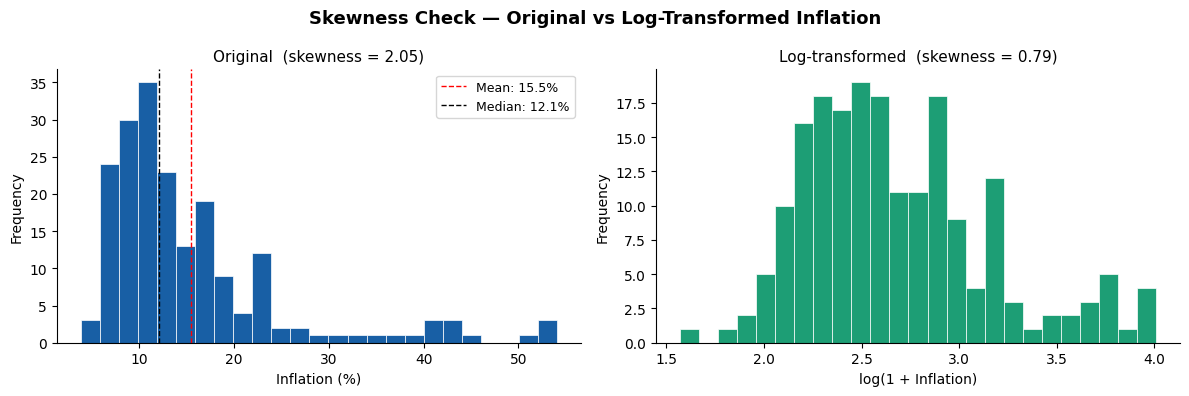

In [32]:
# Plot both distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('white')
fig.suptitle("Skewness Check — Original vs Log-Transformed Inflation",
             fontsize=13, fontweight='bold')

axes[0].hist(df['inflation'].dropna(), bins=25, color='#185FA5',
             edgecolor='white', linewidth=0.5)
axes[0].set_title(f"Original  (skewness = {original_skew:.2f})", fontsize=11)
axes[0].set_xlabel("Inflation (%)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(df['inflation'].mean(), color='red', linestyle='--',
                linewidth=1, label=f"Mean: {df['inflation'].mean():.1f}%")
axes[0].axvline(df['inflation'].median(), color='black', linestyle='--',
                linewidth=1, label=f"Median: {df['inflation'].median():.1f}%")
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].hist(log_series.dropna(), bins=25, color='#1D9E75',
             edgecolor='white', linewidth=0.5)
axes[1].set_title(f"Log-transformed  (skewness = {log_skew:.2f})", fontsize=11)
axes[1].set_xlabel("log(1 + Inflation)")
axes[1].set_ylabel("Frequency")
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/DATA/skewness_check.png', dpi=150, bbox_inches='tight')
plt.show()


In [33]:
#STATIONARITY TESTS

series = df['inflation'].dropna()

adf_stat, adf_p, _, _, adf_cv, _ = adfuller(series)
kpss_stat, kpss_p, _, kpss_cv = kpss(series, regression='c', nlags='auto')

print("\n" + "="*20)
print("STATIONARITY TESTS")
print("="*20)
print(f"  ADF Statistic: {adf_stat:.4f}")
print(f"  KPSS Statistic: {kpss_stat:.4f}")
print(f"  ADF p-value:   {adf_p:.4f}")
print(f"  KPSS p-value:  {kpss_p:.4f}")


STATIONARITY TESTS
  ADF Statistic: -2.0025
  KPSS Statistic: 0.4903
  ADF p-value:   0.2855
  KPSS p-value:  0.0438


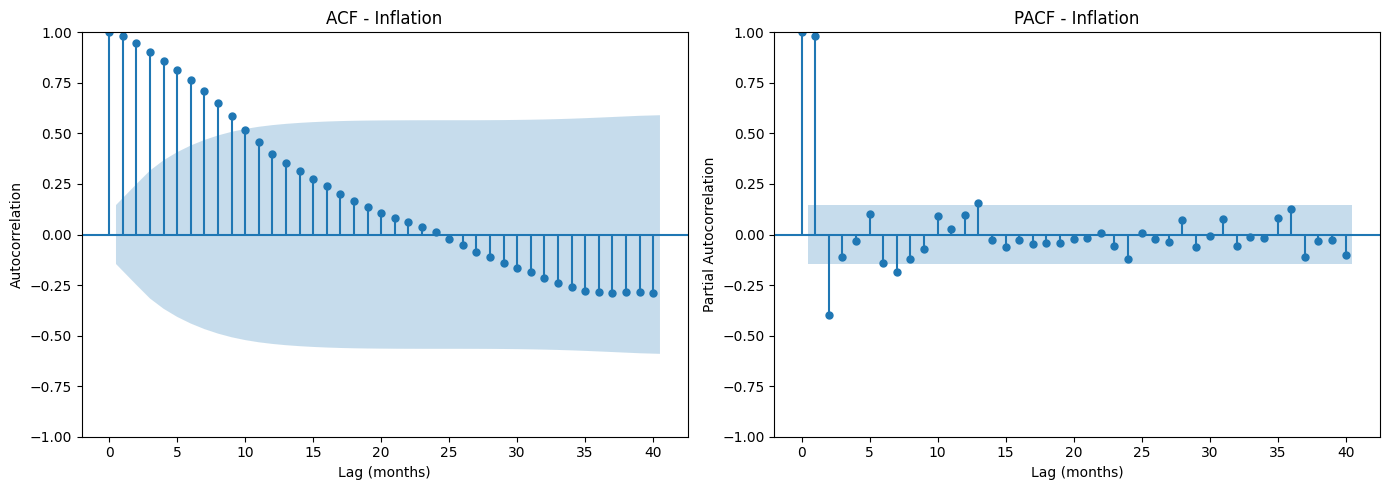

In [45]:
# ACF & PACF ANALYSIS

inflation_series = df_clean['inflation']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# ACF plot
plot_acf(inflation_series, lags=40, ax=axes[0])
axes[0].set_title("ACF - Inflation")
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Autocorrelation")
# PACF plot
plot_pacf(inflation_series, lags=40, ax=axes[1], method='ywm')
axes[1].set_title("PACF - Inflation")
axes[1].set_xlabel("Lag (months)")
axes[1].set_ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/DATA/ACF-PACF.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# Confirming d=1 is sufficient by testing the differenced series
inflation_diff = df['inflation'].dropna().diff().dropna()

adf_stat2, adf_p2, _, _, _, _ = adfuller(inflation_diff)

print("Stationarity test on DIFFERENCED series (d=1):")
print(f"  ADF Statistic: {adf_stat2:.4f}")
print(f"  ADF p-value: {adf_p2:.4f}")

kpss_stat2, kpss_p2, _, _ = kpss(inflation_diff, regression='c', nlags='auto')
print("Stationarity test on DIFFERENCED series (d=1):")
print(f"  KPSS Statistic: {kpss_stat2:.4f}")
print(f"  KPSS p-value:   {kpss_p2:.4f}")

Stationarity test on DIFFERENCED series (d=1):
  ADF Statistic: -4.6227
  ADF p-value: 0.0001
Stationarity test on DIFFERENCED series (d=1):
  KPSS Statistic: 0.1121
  KPSS p-value:   0.1000


/tmp/ipykernel_589/1840400512.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat2, kpss_p2, _, _ = kpss(inflation_diff, regression='c', nlags='auto')


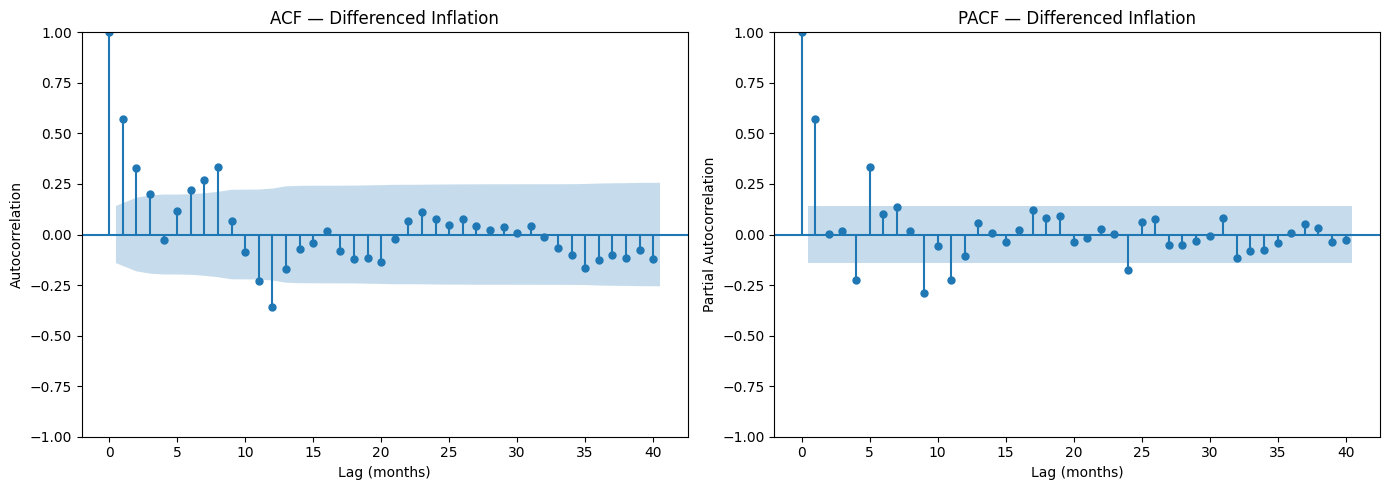

In [36]:
# First difference
inflation_diff = df_clean['inflation'].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(inflation_diff, lags=40, ax=axes[0])
axes[0].set_title("ACF — Differenced Inflation")
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Autocorrelation")

plot_pacf(inflation_diff, lags=40, ax=axes[1], method='ywm')
axes[1].set_title("PACF — Differenced Inflation")
axes[1].set_xlabel("Lag (months)")
axes[1].set_ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/DATA/ACF-PACF_DIFF.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
#STL SEASONAL DECOMPOSITION

print("\n" + "=" * 20)
print("STL SEASONAL DECOMPOSITION")
print("=" * 20)

series_full = df['inflation'].dropna()
stl = STL(series_full, period=12, robust=True)
stl_result = stl.fit()

var_resid   = np.var(stl_result.resid)
var_trend   = np.var(stl_result.trend + stl_result.resid)
var_season  = np.var(stl_result.seasonal + stl_result.resid)

trend_strength    = max(0, 1 - var_resid / var_trend)
seasonal_strength = max(0, 1 - var_resid / var_season)

print(f"\n  Trend strength:    {trend_strength:.3f}")
print(f"  Seasonal strength: {seasonal_strength:.3f}")

if trend_strength > 0.6:
    print("  → Strong trend present.")
if seasonal_strength > 0.6:
    print("  → Strong seasonality present.")
else:
    print("  → Seasonality is mild. Month dummies in ML models will capture this.")







STL SEASONAL DECOMPOSITION

  Trend strength:    0.878
  Seasonal strength: 0.031
  → Strong trend present.
  → Seasonality is mild. Month dummies in ML models will capture this.


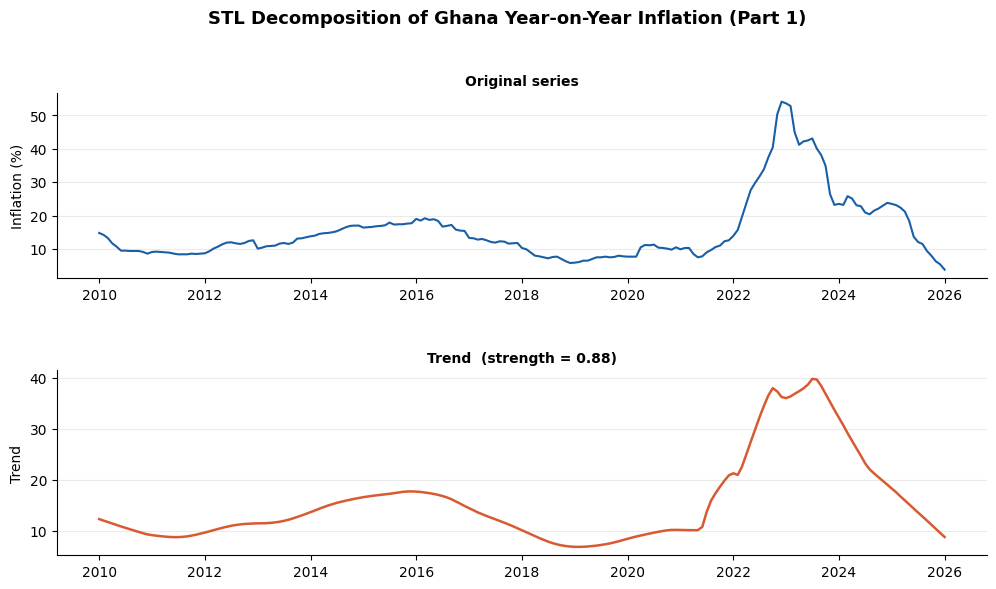

In [38]:
# ============================================================
# PLOT 1: Original Series + Trend
# ============================================================
fig1 = plt.figure(figsize=(12, 6))
fig1.patch.set_facecolor('white')
fig1.suptitle("STL Decomposition of Ghana Year-on-Year Inflation (Part 1)",
             fontsize=13, fontweight='bold', y=1.02)
gs1 = gridspec.GridSpec(2, 1, hspace=0.5)

ax0 = fig1.add_subplot(gs1[0])
ax0.plot(series_full.index, series_full, color='#185FA5', linewidth=1.5)
ax0.set_title("Original series", fontsize=10, fontweight='bold')
ax0.set_ylabel("Inflation (%)")
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax0.xaxis.set_major_locator(mdates.YearLocator(2))
ax0.grid(axis='y', alpha=0.25)

ax1 = fig1.add_subplot(gs1[1])
ax1.plot(series_full.index, stl_result.trend, color='#D85A30', linewidth=1.8)
ax1.set_title(f"Trend  (strength = {trend_strength:.2f})",
              fontsize=10, fontweight='bold')
ax1.set_ylabel("Trend")
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.grid(axis='y', alpha=0.25)


plt.savefig('/content/drive/MyDrive/Colab Notebooks/DATA/stl_part1_original_trend.png', dpi=150, bbox_inches='tight')
plt.show()




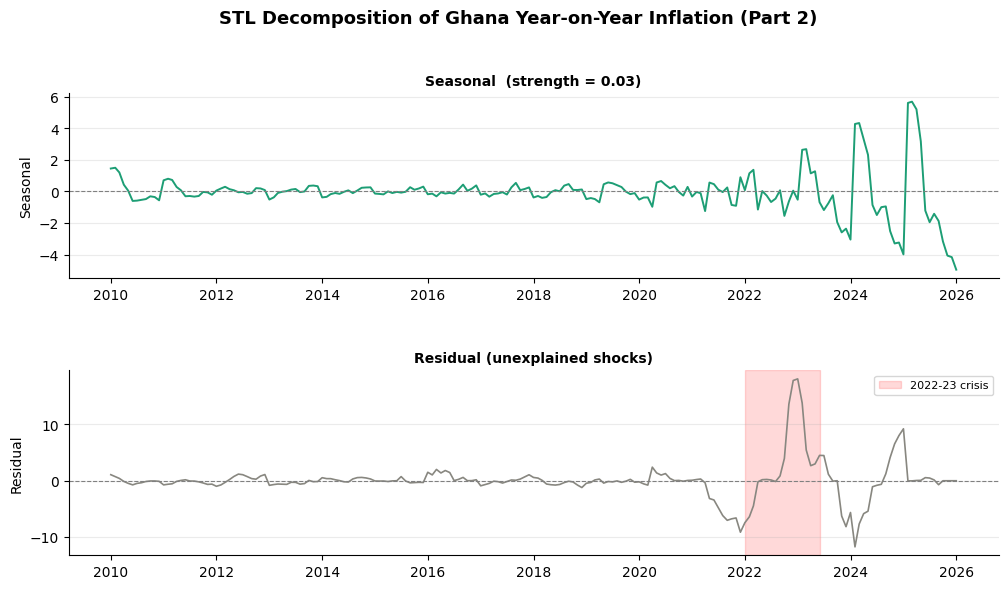

In [39]:
# ============================================================
# PLOT 2: Seasonal + Residual
# ============================================================
fig2 = plt.figure(figsize=(12, 6))
fig2.patch.set_facecolor('white')
fig2.suptitle("STL Decomposition of Ghana Year-on-Year Inflation (Part 2)",
             fontsize=13, fontweight='bold', y=1.02)
gs2 = gridspec.GridSpec(2, 1, hspace=0.5)

ax2 = fig2.add_subplot(gs2[0])
ax2.plot(series_full.index, stl_result.seasonal, color='#1D9E75', linewidth=1.4)
ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax2.set_title(f"Seasonal  (strength = {seasonal_strength:.2f})",
              fontsize=10, fontweight='bold')
ax2.set_ylabel("Seasonal")
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.grid(axis='y', alpha=0.25)

ax3 = fig2.add_subplot(gs2[1])
ax3.plot(series_full.index, stl_result.resid, color='#888780', linewidth=1.2)
ax3.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax3.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2023-06-01'),
            alpha=0.15, color='red', label='2022-23 crisis')
ax3.set_title("Residual (unexplained shocks)", fontsize=10, fontweight='bold')
ax3.set_ylabel("Residual")
ax3.legend(fontsize=8)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.xaxis.set_major_locator(mdates.YearLocator(2))
ax3.grid(axis='y', alpha=0.25)


plt.savefig('/content/drive/MyDrive/Colab Notebooks/DATA/stl_part2_seasonal_residual.png', dpi=150, bbox_inches='tight')
plt.show()


In [40]:
#FEATURE ENGINEERING
df_feat = df.copy()

#a. Lagged inflation (1 to 12 months)
for lag in range(1, 13):
    df_feat[f'inflation_lag{lag}'] = df_feat['inflation'].shift(lag)
#b. Lagged exchange rate (1 to 3 months)
for lag in range(1, 4):
    df_feat[f'exchange_lag{lag}'] = df_feat['exchange_rate'].shift(lag)
#c. Lagged fuel price (1 to 3 months)
   # df_feat[f'fuel_lag{lag}'] = df_feat['fuel_price'].shift(lag)
#d. Rolling moving averages
df_feat['inflation_ma3'] = df_feat['inflation'].shift(1).rolling(3).mean()
df_feat['inflation_ma6'] = df_feat['inflation'].shift(1).rolling(6).mean()
#e. Month-of-year dummies
month_dummies = pd.get_dummies(df_feat.index.month, prefix='month')
month_dummies.index = df_feat.index
df_feat = pd.concat([df_feat, month_dummies], axis=1)

print(f"\n Dataset now has {df_feat.shape[1]} columns.")


 Dataset now has 34 columns.


In [41]:
# DROP ROWS WITH NaN (created by lagging)
df_clean = df_feat.dropna().copy()

print(f"\nRows before dropna: {len(df_feat)}")
print(f"Rows after  dropna: {len(df_clean)}")
print(f"Final usable range: {df_clean.index.min().strftime('%b %Y')} → "
      f"{df_clean.index.max().strftime('%b %Y')}")
print(f"Final shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")


Rows before dropna: 193
Rows after  dropna: 181
Final usable range: Jan 2011 → Jan 2026
Final shape: 181 rows × 34 columns



CORRELATION HEATMAP


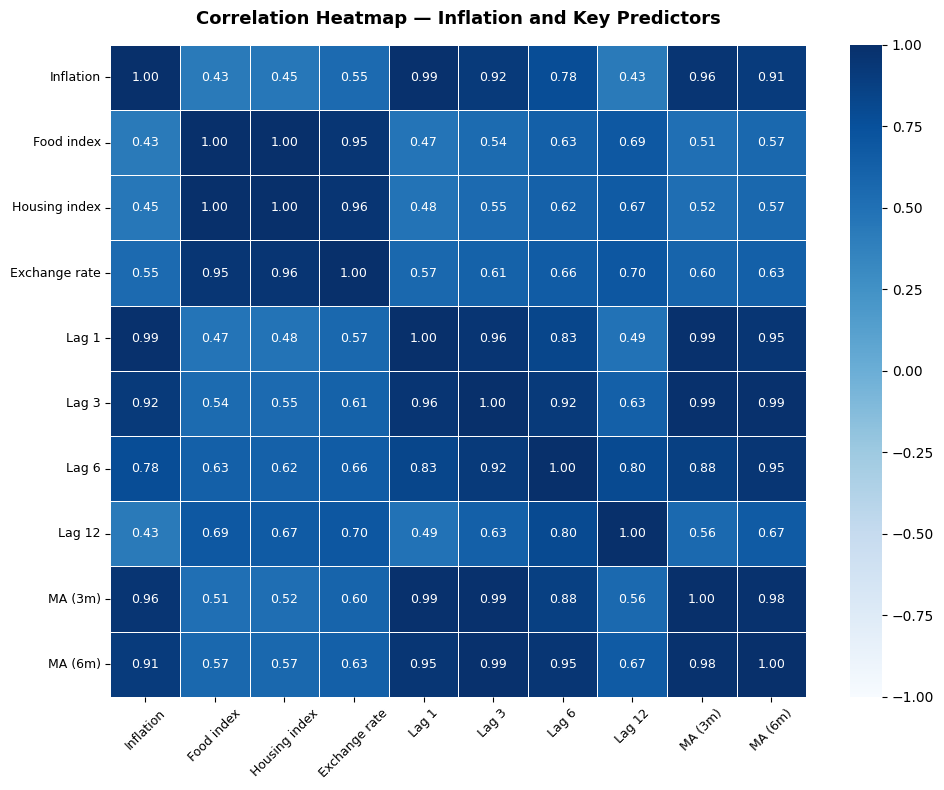

In [42]:
#CORRELATION HEATMAP

print("\n" + "=" * 20)
print("CORRELATION HEATMAP")
print("=" * 20)

# Select only the meaningful variables for the heatmap
key_cols = [
    'inflation',
    'food_index',
    'housing_index',
    'exchange_rate',
    #'fuel_price',
    'inflation_lag1',
    'inflation_lag3',
    'inflation_lag6',
    'inflation_lag12',
    'inflation_ma3',
    'inflation_ma6',
]

corr_matrix = df_clean[key_cols].corr().round(2)

# Rename columns for cleaner labels on the chart
label_map = {
    'inflation':      'Inflation',
    'food_index':     'Food index',
    'housing_index':  'Housing index',
    'exchange_rate':  'Exchange rate',
    #'fuel_price':     'Fuel price',
    'inflation_lag1': 'Lag 1',
    'inflation_lag3': 'Lag 3',
    'inflation_lag6': 'Lag 6',
    'inflation_lag12':'Lag 12',
    'inflation_ma3':  'MA (3m)',
    'inflation_ma6':  'MA (6m)',
}
corr_matrix.rename(index=label_map, columns=label_map, inplace=True)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white')

sns.heatmap(
    corr_matrix,
    annot=True,          # show numbers inside each cell
    fmt='.2f',           # 2 decimal places
    cmap='Blues',        # blue colour scale
    linewidths=0.5,      # thin lines between cells
    linecolor='white',
    ax=ax,
    vmin=-1, vmax=1,     # fix scale from -1 to 1
    annot_kws={'size': 9}
)

ax.set_title("Correlation Heatmap — Inflation and Key Predictors",
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/DATA/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [43]:
# SAVE THE CLEAN DATASET

df_clean.to_csv('/content/drive/MyDrive/Colab Notebooks/DATA/ghana_master.csv')


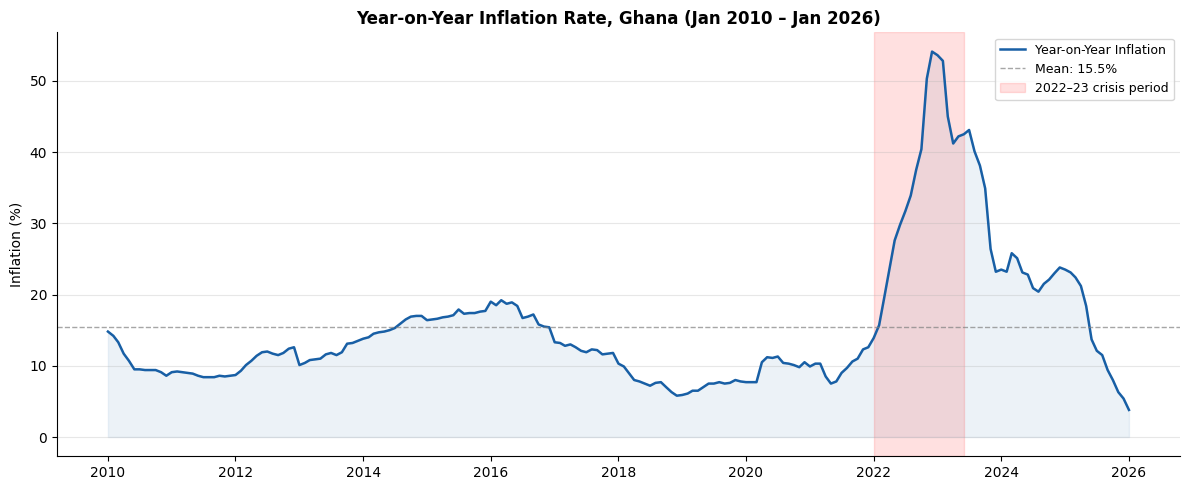

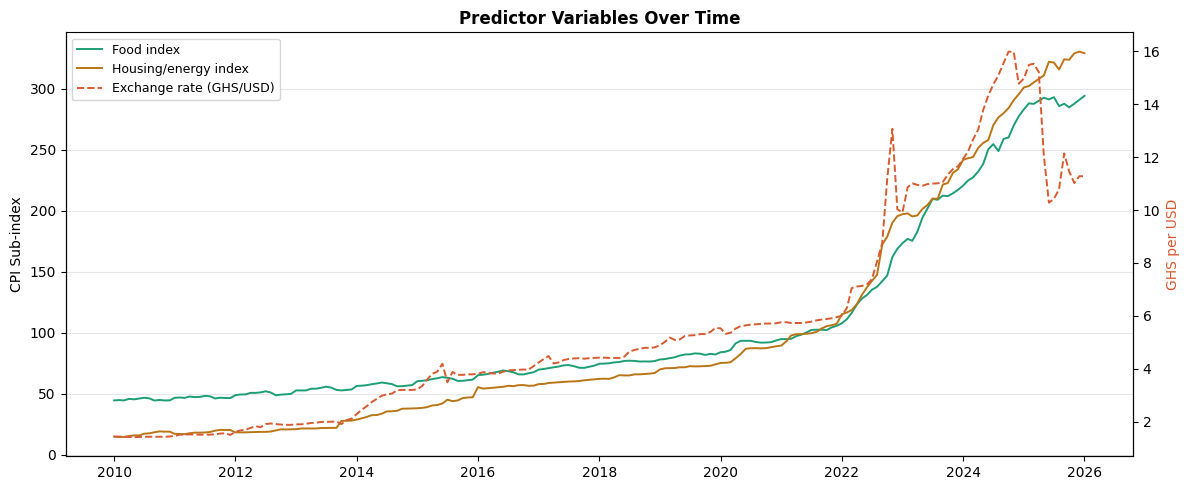

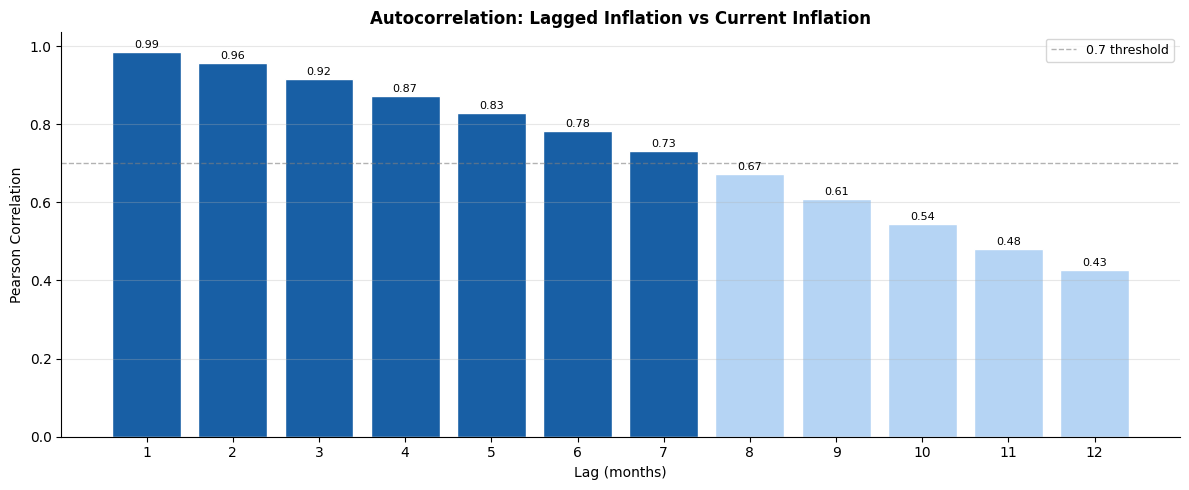

In [44]:
# ── Plot 1: Inflation over time ────────────────────────────
fig1, ax = plt.subplots(figsize=(12, 5))
fig1.patch.set_facecolor('white')
ax.plot(df.index, df['inflation'], color='#185FA5', linewidth=1.8, label='Year-on-Year Inflation')
ax.axhline(df['inflation'].mean(), color='gray', linestyle='--', linewidth=1,
           label=f"Mean: {df['inflation'].mean():.1f}%", alpha=0.7)
ax.fill_between(df.index, df['inflation'], alpha=0.08, color='#185FA5')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2023-06-01'),
           alpha=0.12, color='red', label='2022–23 crisis period')
ax.set_title("Year-on-Year Inflation Rate, Ghana (Jan 2010 – Jan 2026)", fontweight='bold')
ax.set_ylabel("Inflation (%)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/DATA/eda_inflation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: All predictor variables ───────────────────────
fig2, ax = plt.subplots(figsize=(12, 5))
fig2.patch.set_facecolor('white')
ax2r = ax.twinx()
ax.plot(df.index, df['food_index'],    color='#1D9E75', linewidth=1.4, label='Food index')
ax.plot(df.index, df['housing_index'], color='#BA7517', linewidth=1.4, label='Housing/energy index')
ax2r.plot(df.index, df['exchange_rate'], color='#D85A30', linewidth=1.4,
          linestyle='--', label='Exchange rate (GHS/USD)')
ax.set_title("Predictor Variables Over Time", fontweight='bold')
ax.set_ylabel("CPI Sub-index")
ax2r.set_ylabel("GHS per USD", color='#D85A30')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2r.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/DATA/eda_predictors.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3: Lag correlations ───────────────────────────────
fig3, ax = plt.subplots(figsize=(12, 5))
fig3.patch.set_facecolor('white')
lag_corrs = [df_clean['inflation'].corr(df_clean[f'inflation_lag{i}']) for i in range(1,13)]
colors = ['#185FA5' if v > 0.7 else '#B5D4F4' for v in lag_corrs]
ax.bar(range(1,13), lag_corrs, color=colors, edgecolor='white')
ax.axhline(0.7, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='0.7 threshold')
ax.set_title("Autocorrelation: Lagged Inflation vs Current Inflation", fontweight='bold')
ax.set_xlabel("Lag (months)")
ax.set_ylabel("Pearson Correlation")
ax.set_xticks(range(1,13))
ax.legend(fontsize=9)
for i, v in enumerate(lag_corrs):
    ax.text(i+1, v+0.01, f'{v:.2f}', ha='center', fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/DATA/eda_autocorrelation.png', dpi=150, bbox_inches='tight')
plt.show()